In [ ]:
# importing libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

import joblib

import warnings
warnings.filterwarnings("ignore")

In [3]:
DATA_PATH = "../data/india_used_car_prices_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (20000, 13)


,Brand,Model,Body_Type,Variant_Tier,Year,Engine_Size,Battery_kWh,Fuel_Type,Transmission,Mileage,Seats,Owner_Count,Price
0,Kia,Seltos,SUV,Top,2026,1.5,0.0,Diesel,Manual,6292,5,1,1785000
1,Honda,Brio,Hatchback,Top,2019,1.2,0.0,Petrol,Manual,106710,5,1,235000
2,Renault,Kwid,Hatchback,Base,2023,0.8,0.0,Petrol,Manual,45295,5,1,385000
3,Tata,Punch,SUV,Base,2021,1.2,0.0,Petrol,AMT,37453,5,1,520000
4,Maruti Suzuki,Swift,Hatchback,Base,2019,1.3,0.0,Diesel,Manual,104637,5,1,365000


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Rows: 20000
Columns: 13

Column names:
['Brand', 'Model', 'Body_Type', 'Variant_Tier', 'Year', 'Engine_Size', 'Battery_kWh', 'Fuel_Type', 'Transmission', 'Mileage', 'Seats', 'Owner_Count', 'Price']

Data types:
Brand            object
Model            object
Body_Type        object
Variant_Tier     object
Year              int64
Engine_Size     float64
Battery_kWh     float64
Fuel_Type        object
Transmission     object
Mileage           int64
Seats             int64
Owner_Count       int64
Price             int64
dtype: object


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         20000 non-null  object 
 1   Model         20000 non-null  object 
 2   Body_Type     20000 non-null  object 
 3   Variant_Tier  20000 non-null  object 
 4   Year          20000 non-null  int64  
 5   Engine_Size   20000 non-null  float64
 6   Battery_kWh   20000 non-null  float64
 7   Fuel_Type     20000 non-null  object 
 8   Transmission  20000 non-null  object 
 9   Mileage       20000 non-null  int64  
 10  Seats         20000 non-null  int64  
 11  Owner_Count   20000 non-null  int64  
 12  Price         20000 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 2.0+ MB
None


In [6]:
missing_values = df.isnull().sum()
print(missing_values)

Brand           0
Model           0
Body_Type       0
Variant_Tier    0
Year            0
Engine_Size     0
Battery_kWh     0
Fuel_Type       0
Transmission    0
Mileage         0
Seats           0
Owner_Count     0
Price           0
dtype: int64


In [7]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)
missing_percentage

Brand           0.0
Model           0.0
Body_Type       0.0
Variant_Tier    0.0
Year            0.0
Engine_Size     0.0
Battery_kWh     0.0
Fuel_Type       0.0
Transmission    0.0
Mileage         0.0
Seats           0.0
Owner_Count     0.0
Price           0.0
dtype: float64

In [8]:
# checking duplicates
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [9]:
df.describe()

,Year,Engine_Size,Battery_kWh,Mileage,Seats,Owner_Count,Price
count,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,2.000000e+04
mean,2021.544700,1.419140,0.75561,54775.383450,5.290600,1.328250,1.039062e+06
std,2.670048,0.461465,6.05046,42388.990079,0.746712,0.593902,9.920013e+05
min,2015.000000,0.000000,0.00000,777.000000,4.000000,1.000000,7.000000e+04
25%,2020.000000,1.200000,0.00000,23949.750000,5.000000,1.000000,4.900000e+05
50%,2022.000000,1.300000,0.00000,43828.000000,5.000000,1.000000,7.350000e+05
75%,2024.000000,1.500000,0.00000,73855.000000,5.000000,2.000000,1.175000e+06
max,2026.000000,3.200000,82.50000,250000.000000,7.000000,4.000000,9.630000e+06


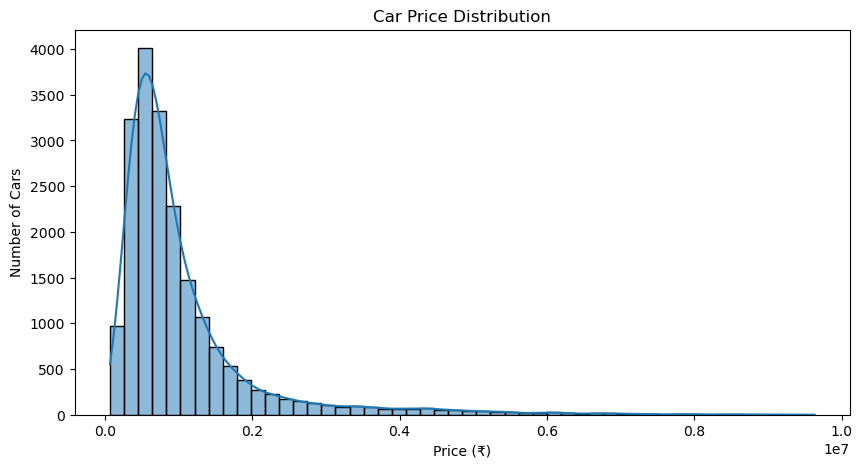

In [11]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Price"], bins=50, kde=True)

plt.title("Car Price Distribution")
plt.xlabel("Price (₹)")
plt.ylabel("Number of Cars")

plt.show()

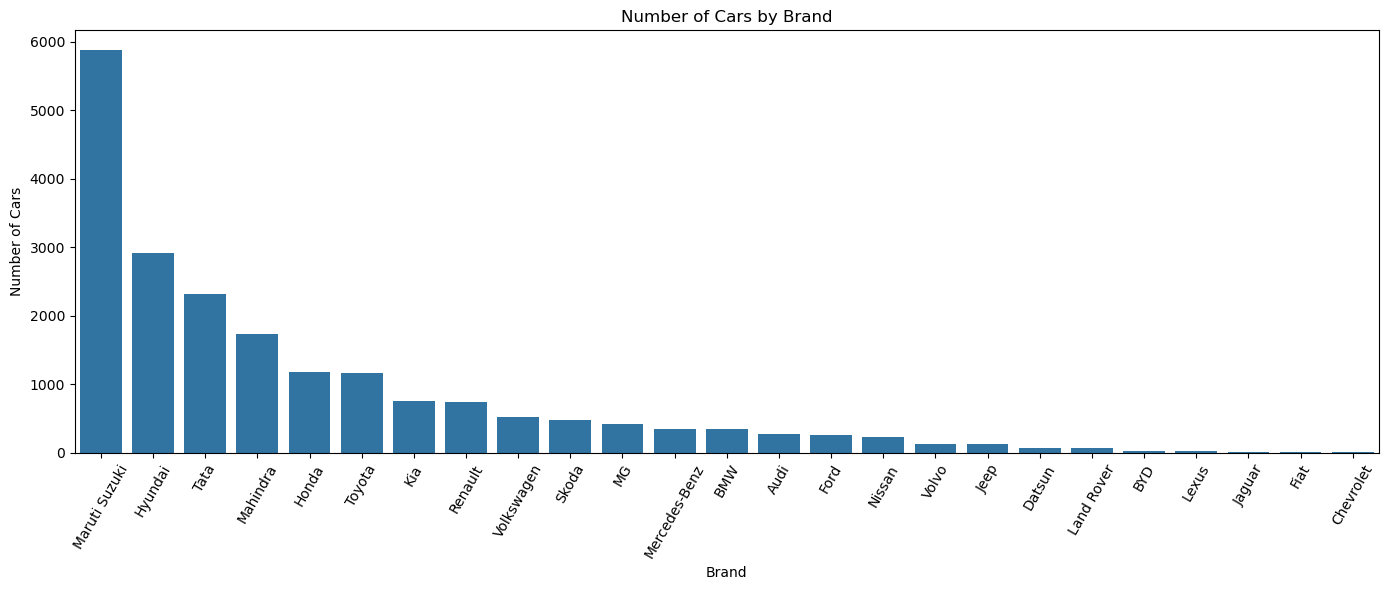

In [12]:
plt.figure(figsize=(14, 6))

brand_counts = df["Brand"].value_counts()

sns.barplot(
    x=brand_counts.index,
    y=brand_counts.values
)

plt.title("Number of Cars by Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Cars")

plt.xticks(rotation=60)
plt.tight_layout()

plt.show()

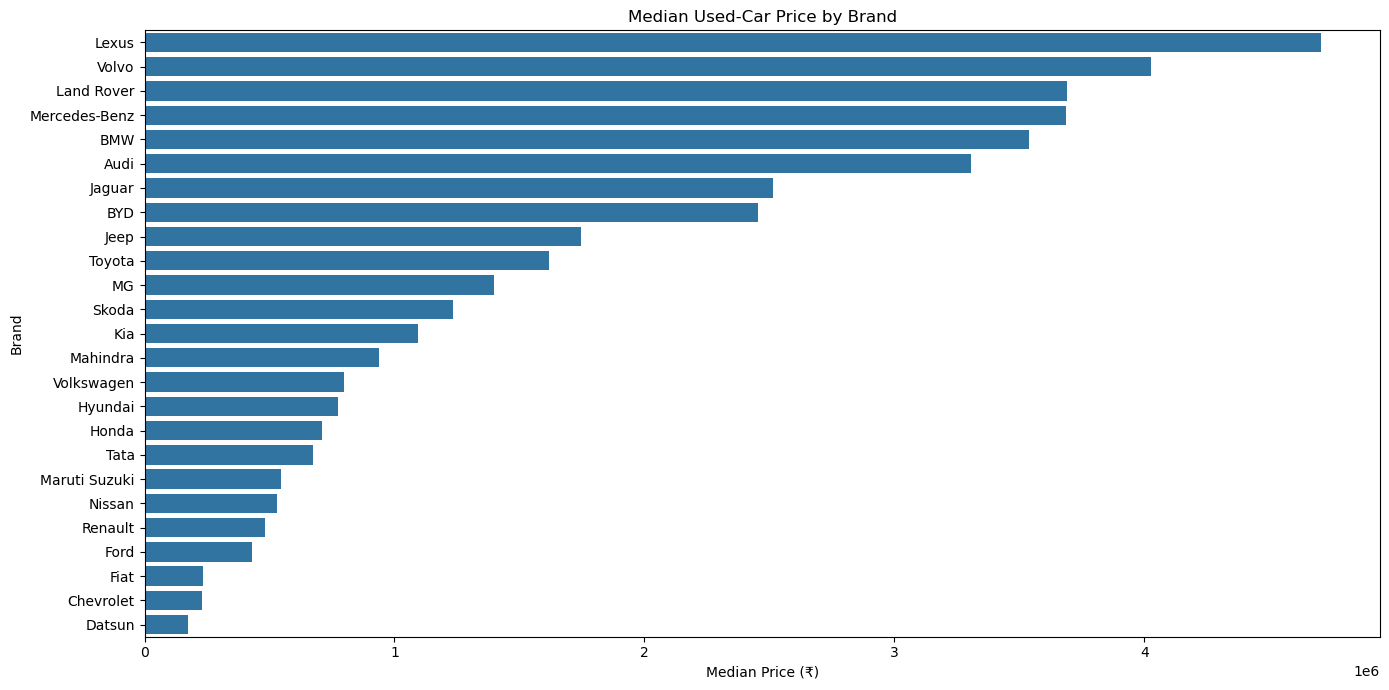

In [13]:
brand_price = (
    df.groupby("Brand")["Price"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 7))

sns.barplot(
    x=brand_price.values,
    y=brand_price.index
)

plt.title("Median Used-Car Price by Brand")
plt.xlabel("Median Price (₹)")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

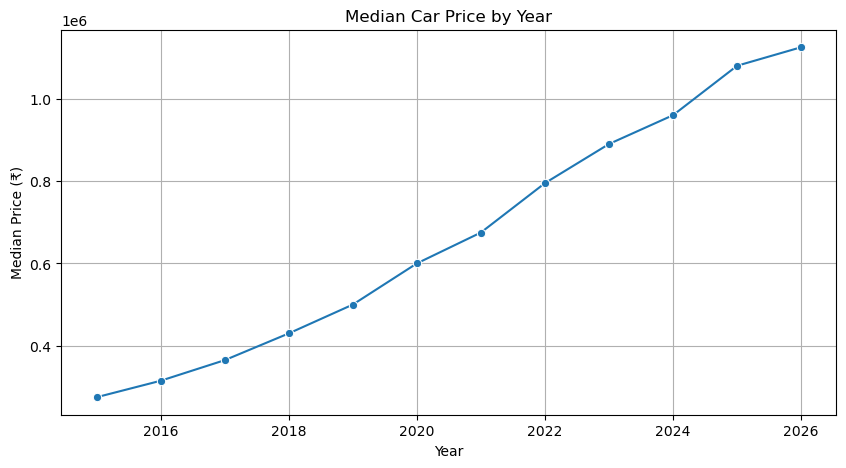

In [14]:
year_price = (
    df.groupby("Year")["Price"]
    .median()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=year_price.index,
    y=year_price.values,
    marker="o"
)

plt.title("Median Car Price by Year")
plt.xlabel("Year")
plt.ylabel("Median Price (₹)")

plt.grid(True)
plt.show()

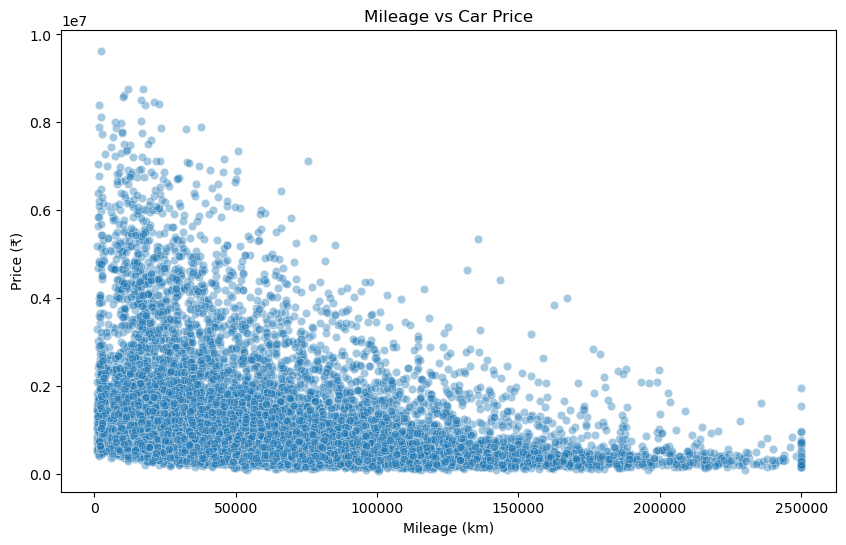

In [15]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Mileage",
    y="Price",
    alpha=0.4
)

plt.title("Mileage vs Car Price")
plt.xlabel("Mileage (km)")
plt.ylabel("Price (₹)")

plt.show()

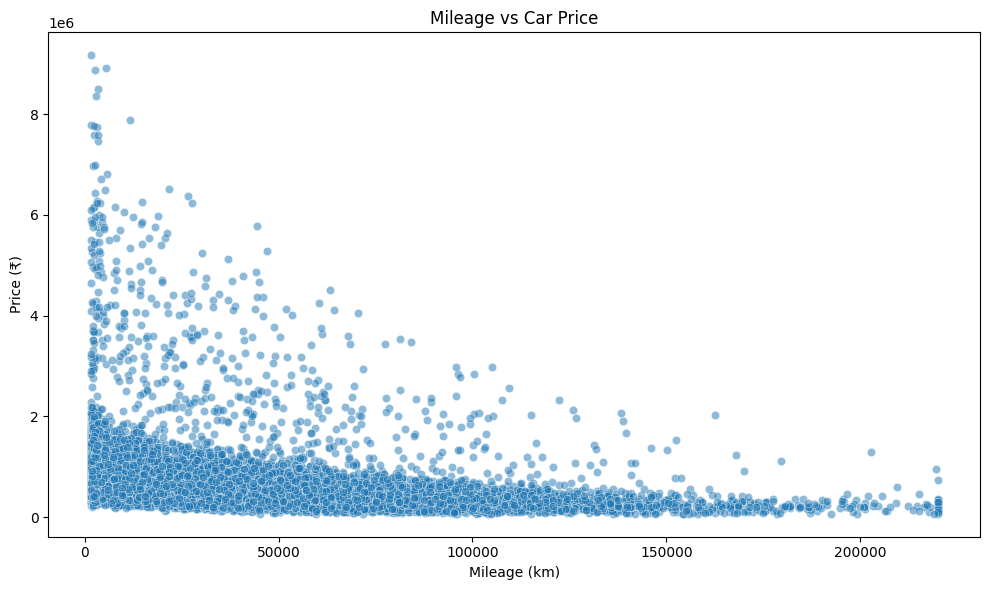

In [16]:
# price vs mileage
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Mileage",
    y="Price",
    alpha=0.5
)

plt.title("Mileage vs Car Price")
plt.xlabel("Mileage (km)")
plt.ylabel("Price (₹)")

plt.tight_layout()
plt.show()

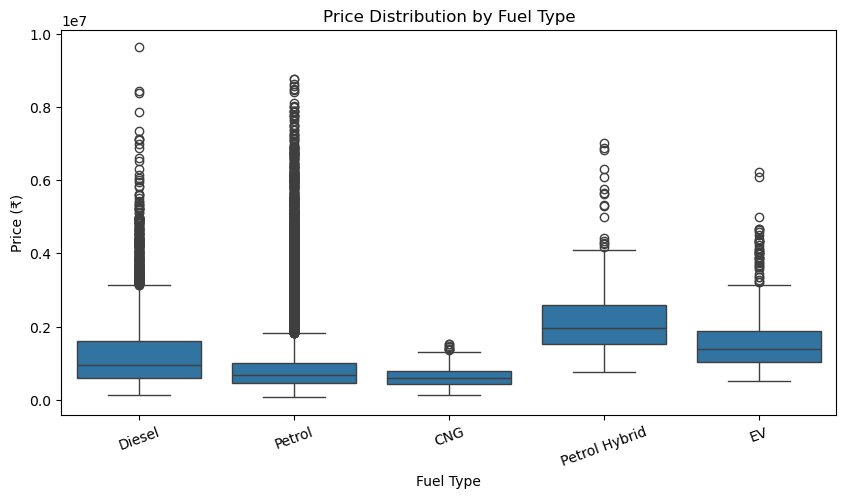

In [16]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Fuel_Type",
    y="Price"
)

plt.title("Price Distribution by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price (₹)")

plt.xticks(rotation=20)
plt.show()

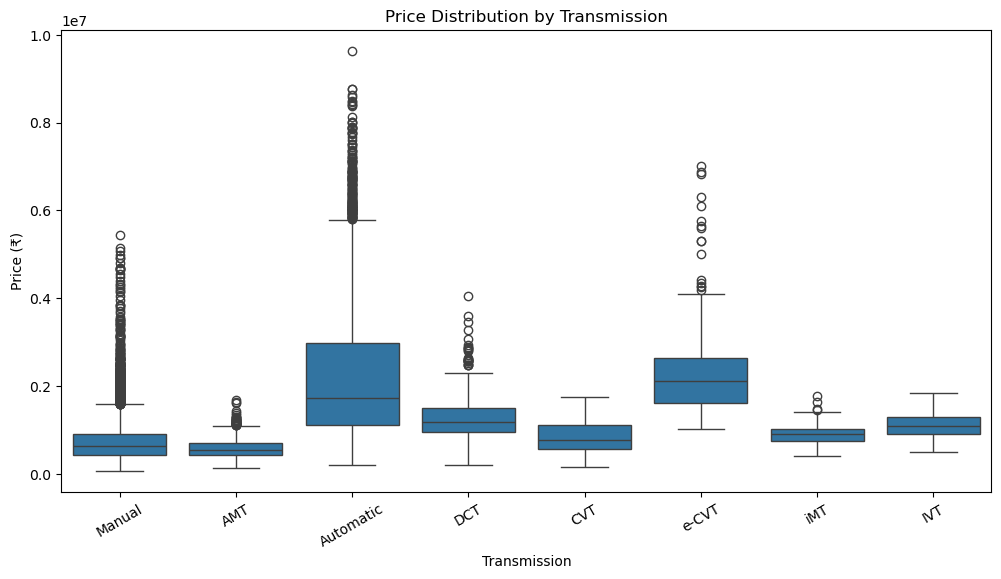

In [17]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Transmission",
    y="Price"
)

plt.title("Price Distribution by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Price (₹)")

plt.xticks(rotation=30)
plt.show()

In [18]:
print("Fuel Type + Transmission combinations:\n")

print(
    pd.crosstab(
        df["Fuel_Type"],
        df["Transmission"]
    )
)

Fuel Type + Transmission combinations:

Transmission    AMT  Automatic  CVT  DCT  IVT  Manual  e-CVT  iMT
Fuel_Type                                                        
CNG               0          0    0    0    0     756      0    0
Diesel          172       1334   14   41    0    3522      0    0
EV                0        349    0    0    0       0      0    0
Petrol         2125       1997  589  594  252    7823      0  159
Petrol Hybrid     0          0    0    0    0      32    241    0


In [19]:
print("\nFuel Type + Engine Size:\n")

print(
    df.groupby("Fuel_Type")["Engine_Size"]
    .agg(["min", "max", "median"])
)


Fuel Type + Engine Size:

                min  max  median
Fuel_Type                       
CNG            0.80  1.5     1.2
Diesel         1.05  3.2     1.6
EV             0.00  0.0     0.0
Petrol         0.80  3.0     1.2
Petrol Hybrid  1.50  2.5     2.0


In [21]:
#mileage per year
df["Mileage_Per_Year"] = (
    df["Mileage"] / df["Car_Age"].replace(0, 1)
)

df["Mileage_Per_Year"] = df["Mileage_Per_Year"].round(2)

df[
    [
        "Year",
        "Car_Age",
        "Mileage",
        "Mileage_Per_Year"
    ]
].head(10)

,Year,Car_Age,Mileage,Mileage_Per_Year
0,2026,0,2221,2221.00
1,2024,2,30129,15064.50
2,2019,7,109801,15685.86
3,2019,7,93599,13371.29
4,2025,1,8330,8330.00
5,2021,5,43282,8656.40
6,2018,8,93363,11670.38
7,2024,2,11357,5678.50
8,2024,2,26958,13479.00
9,2026,0,6171,6171.00


In [20]:
print("\nFuel Type + Battery Capacity:\n")

print(
    df.groupby("Fuel_Type")["Battery_kWh"]
    .agg(["min", "max", "median"])
)


Fuel Type + Battery Capacity:

                min   max  median
Fuel_Type                        
CNG             0.0   0.0     0.0
Diesel          0.0   0.0     0.0
EV             17.3  82.5    40.5
Petrol          0.0   0.0     0.0
Petrol Hybrid   0.0   0.0     0.0


In [21]:
print("EV Transmission combinations:\n")

print(
    df[df["Fuel_Type"] == "EV"]["Transmission"]
    .value_counts()
)

EV Transmission combinations:

Transmission
Automatic    349
Name: count, dtype: int64


In [22]:
print("\nPetrol Hybrid Transmission combinations:\n")

print(
    df[df["Fuel_Type"] == "Petrol Hybrid"]["Transmission"]
    .value_counts()
)


Petrol Hybrid Transmission combinations:

Transmission
e-CVT     241
Manual     32
Name: count, dtype: int64


In [24]:
df["Car_Age"] = 2026 - df["Year"]

df["Mileage_Per_Year"] = (
    df["Mileage"] /
    df["Car_Age"].replace(0, 1)
)

In [25]:
X = df.drop("Price", axis=1)
y = df["Price"]

categorical_features = [
    "Brand",
    "Model",
    "Body_Type",
    "Variant_Tier",
    "Fuel_Type",
    "Transmission"
]

numerical_features = [
    "Year",
    "Engine_Size",
    "Battery_kWh",
    "Mileage",
    "Seats",
    "Owner_Count",
    "Car_Age",
    "Mileage_Per_Year"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nTotal input features:", len(X.columns))

Categorical features:
['Brand', 'Model', 'Body_Type', 'Variant_Tier', 'Fuel_Type', 'Transmission']

Numerical features:
['Year', 'Engine_Size', 'Battery_kWh', 'Mileage', 'Seats', 'Owner_Count', 'Car_Age', 'Mileage_Per_Year']

Total input features: 14


In [26]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16000
Testing samples: 4000


In [28]:
# random forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_predictions = rf_pipeline.predict(X_test)

In [35]:
#evaluate random forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_predictions = rf_pipeline.predict(X_test)
# Evaluate Random Forest

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("---------------------")
print(f"MAE  : ₹{rf_mae:,.2f}")
print(f"RMSE : ₹{rf_rmse:,.2f}")
print(f"R²   : {rf_r2:.4f}")



Random Forest Results
---------------------
MAE  : ₹86,758.64
RMSE : ₹175,224.24
R²   : 0.9713


In [36]:
# xg boost
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)

xgb_pipeline.fit(X_train, y_train)

xgb_predictions = xgb_pipeline.predict(X_test)

In [31]:
# evaluate xgboost
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)

xgb_pipeline.fit(X_train, y_train)

xgb_predictions = xgb_pipeline.predict(X_test)


In [32]:
#model comparision
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("XGBoost Results")
print("----------------")
print(f"MAE  : ₹{xgb_mae:,.2f}")
print(f"RMSE : ₹{xgb_rmse:,.2f}")
print(f"R²   : {xgb_r2:.4f}")

XGBoost Results
----------------
MAE  : ₹74,829.64
RMSE : ₹139,105.79
R²   : 0.9819


In [33]:
test_cars = pd.DataFrame([
    {
        "Brand": "Hyundai",
        "Model": "i20",
        "Body_Type": "Hatchback",
        "Variant_Tier": "Mid",
        "Year": 2019,
        "Engine_Size": 1.2,
        "Battery_kWh": 0,
        "Fuel_Type": "Petrol",
        "Transmission": "Manual",
        "Mileage": 60000,
        "Seats": 5,
        "Owner_Count": 1,
        "Car_Age": 2026 - 2019,
        "Mileage_Per_Year": 60000 / (2026 - 2019)
    },
    {
        "Brand": "Maruti Suzuki",
        "Model": "Swift",
        "Body_Type": "Hatchback",
        "Variant_Tier": "Mid",
        "Year": 2020,
        "Engine_Size": 1.2,
        "Battery_kWh": 0,
        "Fuel_Type": "Petrol",
        "Transmission": "Manual",
        "Mileage": 50000,
        "Seats": 5,
        "Owner_Count": 1,
        "Car_Age": 2026 - 2020,
        "Mileage_Per_Year": 50000 / (2026 - 2020)
    }
])

In [34]:
rf_test_predictions = rf_pipeline.predict(test_cars)

xgb_test_predictions = xgb_pipeline.predict(test_cars)

for i in range(len(test_cars)):
    print(
        f"{test_cars.iloc[i]['Brand']} "
        f"{test_cars.iloc[i]['Model']} "
        f"{test_cars.iloc[i]['Year']}"
    )

    print(
        f"Random Forest: ₹{rf_test_predictions[i]:,.0f}"
    )

    print(
        f"XGBoost: ₹{xgb_test_predictions[i]:,.0f}"
    )

    print("-" * 50)

Hyundai i20 2019
Random Forest: ₹440,483
XGBoost: ₹475,438
--------------------------------------------------
Maruti Suzuki Swift 2020
Random Forest: ₹504,217
XGBoost: ₹469,891
--------------------------------------------------


In [37]:
# Compare actual vs predicted prices

comparison = pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": xgb_predictions
})

comparison["Error"] = (
    comparison["Predicted_Price"] -
    comparison["Actual_Price"]
)

comparison["Absolute_Error"] = (
    comparison["Error"].abs()
)

print("Overall:")
print(comparison.describe())

print("\nLargest prediction errors:")
print(
    comparison
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
)

Overall:
       Actual_Price  Predicted_Price         Error  Absolute_Error
count  4.000000e+03     4.000000e+03  4.000000e+03    4.000000e+03
mean   1.050065e+06     1.046916e+06 -3.149340e+03    7.482964e+04
std    1.035011e+06     9.980761e+05  1.390875e+05    1.172791e+05
min    9.000000e+04     7.821769e+04 -2.086498e+06    1.968750e+00
25%    4.900000e+05     4.995324e+05 -4.022406e+04    1.838689e+04
50%    7.400000e+05     7.414438e+05  3.279828e+03    4.296316e+04
75%    1.176250e+06     1.169970e+06  4.532428e+04    8.357222e+04
max    9.630000e+06     8.170226e+06  1.064268e+06    2.086498e+06

Largest prediction errors:
      Actual_Price  Predicted_Price       Error  Absolute_Error
77         9630000       7543502.50 -2086497.50      2086497.50
2308       7130000       5796449.00 -1333551.00      1333551.00
2148       8620000       7365029.50 -1254970.50      1254970.50
3129       5845000       4637442.00 -1207558.00      1207558.00
536        8420000       7229793.50 -119

In [38]:
# Performance by price segment

comparison["Price_Segment"] = pd.cut(
    comparison["Actual_Price"],
    bins=[0, 500000, 1000000, 2000000, 5000000, np.inf],
    labels=[
        "Below ₹5L",
        "₹5L–₹10L",
        "₹10L–₹20L",
        "₹20L–₹50L",
        "Above ₹50L"
    ]
)

segment_results = comparison.groupby(
    "Price_Segment",
    observed=True
).agg(
    Count=("Actual_Price", "count"),
    MAE=("Absolute_Error", "mean"),
    Actual_Median=("Actual_Price", "median"),
    Predicted_Median=("Predicted_Price", "median")
)

segment_results

,Count,MAE,Actual_Median,Predicted_Median
Price_Segment,,,,
Below ₹5L,1044,31297.709531,365000.0,3.793639e+05
₹5L–₹10L,1666,48066.958677,705000.0,7.103626e+05
₹10L–₹20L,883,89546.636254,1290000.0,1.290565e+06
₹20L–₹50L,338,208857.584320,2752500.0,2.699193e+06
Above ₹50L,69,534792.144928,5845000.0,5.708180e+06


In [39]:
# Inspect the largest prediction errors with car details

error_analysis = X_test.copy()

error_analysis["Actual_Price"] = y_test.values
error_analysis["Predicted_Price"] = xgb_predictions
error_analysis["Absolute_Error"] = (
    error_analysis["Actual_Price"] -
    error_analysis["Predicted_Price"]
).abs()

largest_errors = (
    error_analysis
    .sort_values("Absolute_Error", ascending=False)
    .head(20)
)

largest_errors[
    [
        "Brand",
        "Model",
        "Year",
        "Fuel_Type",
        "Engine_Size",
        "Mileage",
        "Actual_Price",
        "Predicted_Price",
        "Absolute_Error"
    ]
]

,Brand,Model,Year,Fuel_Type,Engine_Size,Mileage,Actual_Price,Predicted_Price,Absolute_Error
980,Mercedes-Benz,GLE,2026,Diesel,2.0,2174,9630000,7543502.50,2086497.50
18002,Mercedes-Benz,GLE,2023,Diesel,2.0,75638,7130000,5796449.00,1333551.00
4463,BMW,X5,2025,Petrol,3.0,10325,8620000,7365029.50,1254970.50
10299,Mercedes-Benz,GLE,2020,Diesel,2.0,44829,5845000,4637442.00,1207558.00
18079,Mercedes-Benz,GLE,2024,Diesel,2.0,22732,8420000,7229793.50,1190206.50
2621,BMW,5 Series,2024,Petrol,2.0,10482,6370000,5223657.00,1146343.00
3268,Audi,Q7,2019,Diesel,3.0,80025,3700000,2585984.25,1114015.75
14066,BMW,5 Series,2025,Petrol,2.0,11550,7365000,6254976.00,1110024.00
17099,BMW,X5,2019,Diesel,3.0,108502,3990000,2899355.25,1090644.75
1402,BMW,X5,2022,Diesel,3.0,69639,5825000,4755501.50,1069498.50


In [40]:
luxury_models = [
    "GLE",
    "X5",
    "5 Series",
    "Q7",
    "E-Class",
    "Range Rover Evoque",
    "GLC"
]

luxury_check = (
    df[df["Model"].isin(luxury_models)]
    .groupby(["Brand", "Model"])
    .agg(
        Count=("Price", "size"),
        Min_Price=("Price", "min"),
        Median_Price=("Price", "median"),
        Max_Price=("Price", "max"),
        Avg_Price=("Price", "mean")
    )
    .sort_values("Count", ascending=False)
)

luxury_check

,,Count,Min_Price,Median_Price,Max_Price,Avg_Price
Brand,Model,,,,,
Mercedes-Benz,E-Class,76,1420000,4610000.0,8395000,4.713618e+06
BMW,5 Series,73,1730000,4860000.0,7365000,4.536164e+06
Mercedes-Benz,GLC,70,1690000,3802500.0,7225000,4.220929e+06
Audi,Q7,34,1540000,6150000.0,8500000,5.708824e+06
BMW,X5,32,1770000,6477500.0,8765000,5.913125e+06
Land Rover,Range Rover Evoque,30,1030000,3687500.0,5680000,3.575500e+06
Mercedes-Benz,GLE,29,1945000,5505000.0,9630000,5.281379e+06


In [41]:
df[df["Model"].isin(luxury_models)][
    [
        "Brand",
        "Model",
        "Variant_Tier",
        "Year",
        "Engine_Size",
        "Fuel_Type",
        "Transmission",
        "Mileage",
        "Price"
    ]
].sort_values("Price", ascending=False).head(30)

,Brand,Model,Variant_Tier,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Price
980,Mercedes-Benz,GLE,Mid,2026,2.0,Diesel,Automatic,2174,9630000
5974,BMW,X5,Top,2023,3.0,Petrol,Automatic,11846,8765000
4463,BMW,X5,Base,2025,3.0,Petrol,Automatic,10325,8620000
19876,Audi,Q7,Top,2024,3.0,Petrol,Automatic,16487,8500000
13607,BMW,X5,Top,2023,3.0,Petrol,Automatic,21032,8465000
18079,Mercedes-Benz,GLE,Mid,2024,2.0,Diesel,Automatic,22732,8420000
7021,Mercedes-Benz,E-Class,Top,2026,2.0,Petrol,Automatic,1494,8395000
2793,Mercedes-Benz,GLE,Mid,2025,2.0,Diesel,Automatic,17820,8385000
15979,Mercedes-Benz,E-Class,Top,2026,2.0,Petrol,Automatic,2414,8115000
1971,BMW,X5,Mid,2025,3.0,Petrol,Automatic,7191,8005000


In [42]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

tuned_xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

tuned_xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", tuned_xgb)
    ]
)

tuned_xgb_pipeline.fit(X_train, y_train)

tuned_predictions = tuned_xgb_pipeline.predict(X_test)

tuned_mae = mean_absolute_error(
    y_test,
    tuned_predictions
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_predictions
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_predictions
)

print("Tuned XGBoost Results")
print("---------------------")
print(f"MAE  : ₹{tuned_mae:,.2f}")
print(f"RMSE : ₹{tuned_rmse:,.2f}")
print(f"R²   : {tuned_r2:.4f}")

Tuned XGBoost Results
---------------------
MAE  : ₹73,209.53
RMSE : ₹139,634.88
R²   : 0.9818


In [43]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    xgb_pipeline,
    "../models/car_price_model.pkl"
)

print(" Final XGBoost model saved successfully!")
print(" Location: ../models/car_price_model.pkl")

 Final XGBoost model saved successfully!
 Location: ../models/car_price_model.pkl
